# Phishing URL Classification — Data Preprocessing

**Dataset:** `phishing_urls.csv` (~235K URLs, 55 columns)

**Label:** 1 = Legitimate, 0 = Phishing

### Steps
1. Load data
2. Drop raw-text columns
3. Handle missing values (verified none exist)
4. Encode the `TLD` categorical variable
5. Treat outliers (IQR-based capping on count/length features)
6. Train / validation / test split
7. Scale continuous features
8. Save preprocessed artefacts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings, os, pickle

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

SEED      = 42
DATA_PATH = '../data/phishing_urls.csv'
OUT_DIR   = '../data/processed/'
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (235795, 55)


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1


## 2. Missing Values

EDA confirmed **no missing values**. We verify programmatically before proceeding. If any were present the appropriate strategy would be:
- **Numeric features**: median imputation (robust to skew).
- **Categorical features**: mode imputation or a dedicated `'Unknown'` level.

In [3]:
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print('No missing values — no imputation required.')
else:
    print('Columns with missing values:')
    print(missing)
    for col in missing.index:
        if df[col].dtype != object:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

No missing values — no imputation required.


## 3. Drop Raw-Text Columns

`URL`, `Domain`, and `Title` are free-text identifiers. All discriminative information they carry is already captured by the numeric features engineered during dataset construction (e.g. `URLLength`, `DomainLength`, `DomainTitleMatchScore`). Keeping them would leak row identity and bloat memory.

We keep `TLD` for now and encode it in Step 4.

In [4]:
DROP_TEXT = ['URL', 'Domain', 'Title']
df = df.drop(columns=DROP_TEXT)
print(f'Shape after dropping text columns: {df.shape}')

Shape after dropping text columns: (235795, 52)


## 4. Inspect the `TLD` Categorical Variable

`TLD` (top-level domain) is the only remaining categorical column. It has **high cardinality** (many unique TLDs), making one-hot encoding impractical. We use two compact numeric encodings:

| New feature | What it captures |
|---|---|
| `TLD_freq` | How common the TLD is in the training set (frequency encoding) |
| `TLD_phishing_rate` | Fraction of URLs with this TLD that are phishing (target encoding, fit on train labels only) |

Note: `TLDLegitimateProb` (an externally-sourced prior) is already present; our `TLD_phishing_rate` is an in-sample complement.

Both encodings are **deferred until after the train/test split** (Step 6) to prevent data leakage. The raw `TLD` column is excluded from outlier treatment.

In [5]:
print(f'Unique TLDs: {df["TLD"].nunique()}')
print(df['TLD'].value_counts().head(10))

Unique TLDs: 695
TLD
com    112554
org     18793
net      7097
app      6508
uk       6395
co       5422
io       4201
de       3996
ru       3875
au       2979
Name: count, dtype: int64


In [6]:
# TLD encoding is deferred until after the train/test split (Step 6)
# to prevent data leakage from test labels and test TLD frequencies.
# The raw TLD column is kept here and dropped from each split after encoding.
print(f'TLD column retained for post-split encoding.')
print(f'Shape: {df.shape}')

TLD column retained for post-split encoding.
Shape: (235795, 52)


## 5. Outlier Inspection

We inspect count/length features for extreme values but **intentionally do not apply any capping or transformation**.

**Why not cap?**  
Phishing pages frequently exhibit genuinely extreme behaviour — heavily obfuscated JavaScript, unusually long URLs designed to obscure the true domain, thousands of embedded links, or massive inline content. These extremes are *part of the signal*, not noise. Capping would discard exactly the information that distinguishes sophisticated phishing attempts from legitimate pages.

**Why not log-transform?**  
Log-transforming would benefit linear models but compresses contrast at the high end, softening the same discriminative signal. Our tree-based models (RF, XGBoost) are rank-invariant and gain nothing from it. For linear models (Lasso, Ridge, Logistic, Elastic Net), regularisation already limits the influence of extreme values on coefficients.

**What we do check:**  
- Skewness and the ratio of max to Q3 (a simple extreme-value indicator).  
- Whether any outliers are plausibly **data errors** (e.g. negative counts, zero-length URLs) rather than genuine behaviour. Those would be removed.

In [7]:
label_col   = 'label'
binary_cols = [c for c in df.columns
               if c not in (label_col, 'TLD') and df[c].nunique() <= 2]
ratio_cols  = [c for c in df.columns
               if c not in (label_col, 'TLD')
               and c not in binary_cols
               and df[c].between(0, 1).all()]
count_cols  = [c for c in df.columns
               if c not in (label_col, 'TLD')
               and c not in binary_cols
               and c not in ratio_cols]

print(f'Binary features : {len(binary_cols)}')
print(f'Ratio features  : {len(ratio_cols)}')
print(f'Count features  : {len(count_cols)}')

Binary features : 19
Ratio features  : 7
Count features  : 24


In [8]:
# --- Outlier summary for count/length features ---
records = []
for col in count_cols:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    fence = q3 + 3 * iqr
    n_extreme = int((df[col] > fence).sum())
    records.append({
        'feature'    : col,
        'min'        : df[col].min(),
        'Q3'         : q3,
        'max'        : df[col].max(),
        'skewness'   : round(df[col].skew(), 2),
        'n_beyond_3IQR': n_extreme,
        'pct_beyond_3IQR': round(100 * n_extreme / len(df), 3),
    })

outlier_summary = (pd.DataFrame(records)
                     .set_index('feature'))

print('Count/length features — extreme value summary (sorted by max/Q3 ratio):')
outlier_summary

Count/length features — extreme value summary (sorted by max/Q3 ratio):


,min,Q3,max,skewness,n_beyond_3IQR,pct_beyond_3IQR
feature,,,,,,
URLLength,13.000000,34.0,6097.0,53.32,13404,5.685
DomainLength,4.000000,24.0,110.0,2.51,3826,1.623
URLSimilarityIndex,0.155574,100.0,100.0,-0.99,0,0.000
TLDLength,2.000000,3.0,13.0,1.66,563,0.239
NoOfSubDomain,0.000000,1.0,10.0,1.81,43406,18.408
NoOfObfuscatedChar,0.000000,0.0,447.0,204.68,485,0.206
NoOfLettersInURL,0.000000,20.0,5191.0,58.40,11592,4.916
NoOfDegitsInURL,0.000000,0.0,2011.0,94.88,51461,21.824
NoOfEqualsInURL,0.000000,0.0,176.0,114.99,5401,2.291


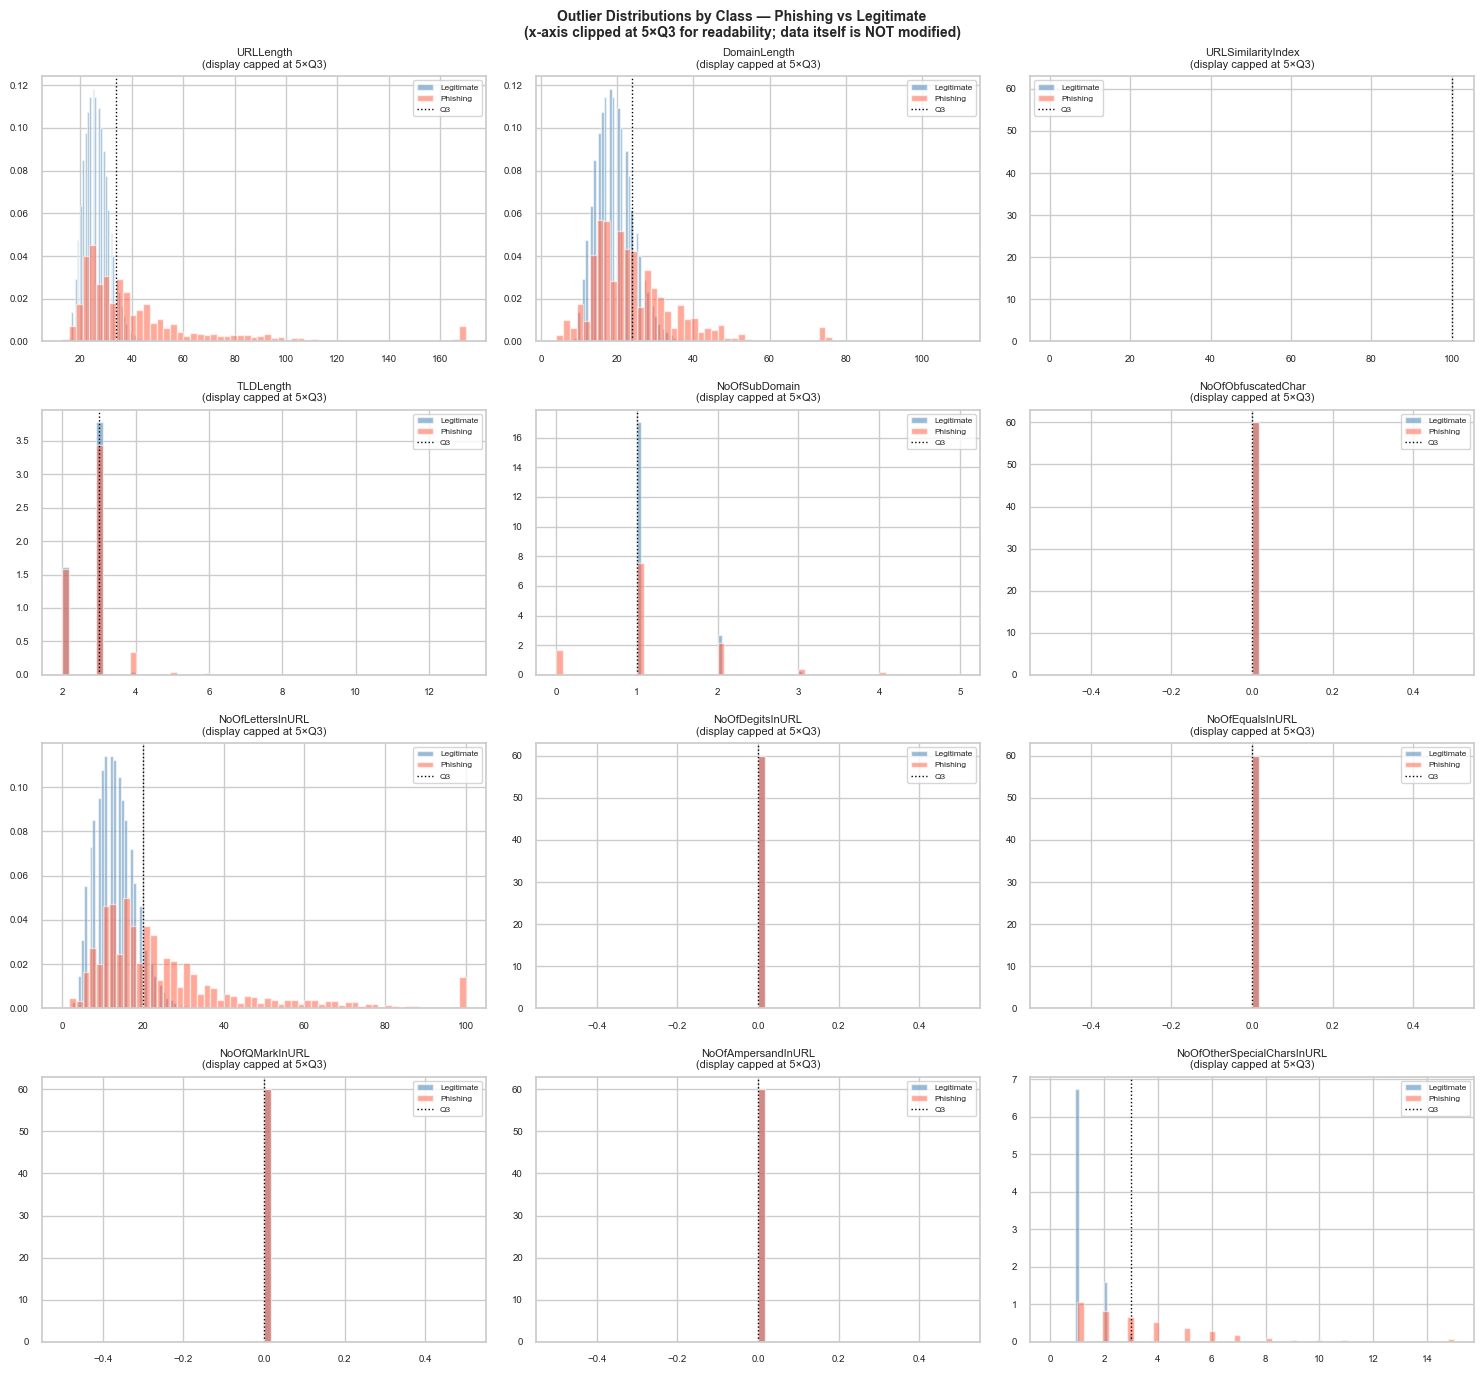

In [9]:
# --- Outlier distribution plots, stratified by class ---
# Showing phishing vs legitimate separately reveals whether extreme values
# are concentrated in one class — confirming they carry signal worth keeping.

N_PLOT = 12 
plot_cols = outlier_summary.head(N_PLOT).index.tolist()

ncols = 3
nrows = int(np.ceil(N_PLOT / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = axes.flatten()

colors = {1: ('steelblue', 'Legitimate'), 0: ('tomato', 'Phishing')}

for ax, col in zip(axes, plot_cols):
    cap_val = outlier_summary.loc[col, 'Q3'] * 5  # visual x-limit: 5×Q3 to keep plots readable
    for label, (color, name) in colors.items():
        vals = df.loc[df[label_col] == label, col]
        vals_clipped = vals.clip(upper=cap_val)  # clip only for display, not saved to df
        ax.hist(vals_clipped, bins=60, color=color, alpha=0.55, label=name, density=True)
    ax.axvline(df[col].quantile(0.75), color='black', linestyle=':', linewidth=1, label='Q3')
    ax.set_title(f'{col}\n(display capped at 5×Q3)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=6)

for ax in axes[N_PLOT:]:
    ax.set_visible(False)

plt.suptitle(
    'Outlier Distributions by Class — Phishing vs Legitimate\n'
    '(x-axis clipped at 5×Q3 for readability; data itself is NOT modified)',
    fontweight='bold', fontsize=10
)
plt.tight_layout()
plt.show()

In [10]:
# Check for data errors (impossible values)
# Count/length features should be non-negative; a few (e.g. URLLength, DomainLength)
# must be strictly positive for a valid URL record.
strictly_positive = ['URLLength', 'DomainLength']

errors = {}

# 1. Negative values in any count feature
for col in count_cols:
    n_neg = int((df[col] < 0).sum())
    if n_neg:
        errors[col] = errors.get(col, [])
        errors[col].append(f'{n_neg} negative values')

# 2. Zero values in features that must be strictly positive
for col in strictly_positive:
    if col in df.columns:
        n_zero = int((df[col] == 0).sum())
        if n_zero:
            errors[col] = errors.get(col, [])
            errors[col].append(f'{n_zero} zero values (impossible for a valid URL)')

if errors:
    print("Error detected in count/length features.")
else:
    print('No data errors detected — all count/length values are valid.')


No data errors detected — all count/length values are valid.


## 6. Train / Validation / Test Split

We split **before** fitting the scaler (and before re-estimating the TLD target encoding) to prevent data leakage.

| Split | Proportion | Purpose |
|---|---|---|
| Train | 70% | Model fitting & scaler fitting |
| Validation | 15% | Hyperparameter tuning |
| Test | 15% | Final unbiased evaluation |

Stratified splitting preserves the class ratio (~54% legitimate / ~46% phishing) across all splits.

In [11]:
X = df.drop(columns=[label_col])
y = df[label_col]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)
    
print(f'Train      : {X_train.shape[0]:>7,}  (legitimate rate = {y_train.mean():.3f})')
print(f'Validation : {X_val.shape[0]:>7,}  (legitimate rate = {y_val.mean():.5f})')
print(f'Test       : {X_test.shape[0]:>7,}  (legitimate rate = {y_test.mean():.5f})')

Train      : 165,056  (legitimate rate = 0.572)
Validation :  35,369  (legitimate rate = 0.57188)
Test       :  35,370  (legitimate rate = 0.57190)


### TLD Encoding (post-split)

Both TLD encodings are computed here using **training data only** to prevent leakage:

| New feature | Encoding | Fallback for unseen TLDs |
|---|---|---|
| `TLD_freq` | Frequency in training set | `0` |
| `TLD_phishing_rate` | Phishing rate in training set | Global train phishing rate |

The raw `TLD` column is dropped from all splits after encoding.

In [12]:
# Frequency encoding — fit on train only
tld_freq_map = X_train['TLD'].value_counts(normalize=True)
X_train['TLD_freq'] = X_train['TLD'].map(tld_freq_map)
X_val['TLD_freq']   = X_val['TLD'].map(tld_freq_map).fillna(0)
X_test['TLD_freq']  = X_test['TLD'].map(tld_freq_map).fillna(0)

# Target encoding — fit on train labels only
tld_phish_map   = y_train.groupby(X_train['TLD']).apply(lambda s: (s == 0).mean())
global_fallback = (y_train == 0).mean()
X_train['TLD_phishing_rate'] = X_train['TLD'].map(tld_phish_map)
X_val['TLD_phishing_rate']   = X_val['TLD'].map(tld_phish_map).fillna(global_fallback)
X_test['TLD_phishing_rate']  = X_test['TLD'].map(tld_phish_map).fillna(global_fallback)

# Drop raw TLD from all splits
X_train = X_train.drop(columns=['TLD'])
X_val   = X_val.drop(columns=['TLD'])
X_test  = X_test.drop(columns=['TLD'])

print(f'Shape after TLD encoding: {X_train.shape}')
X_train[['TLD_freq', 'TLD_phishing_rate']].describe().round(4)

Shape after TLD encoding: (165056, 52)


,TLD_freq,TLD_phishing_rate
count,165056.0000,165056.0000
mean,0.2391,0.4281
std,0.2280,0.2746
min,0.0000,0.0000
25%,0.0094,0.2861
50%,0.0799,0.3892
75%,0.4770,0.4008
max,0.4770,1.0000


## 7. Feature Scaling

Different model families have different scaling requirements:

| Models | Scaling needed? | Reason |
|---|---|---|
| Lasso, Ridge, Elastic Net, Logistic Regression, Forward/Backward Selection | **Yes** | Coefficients and regularisation penalties are on the same scale; unscaled features dominate purely due to magnitude |
| Random Forest, XGBoost | **No** | Split-based, rank-invariant, so scaling has little effect |

We produce **two sets of splits**:

- **Scaled** (`_lin` suffix) — `StandardScaler` applied to all count + ratio features; used for linear/regularised models.
- **Unscaled** (`_tree` suffix) — features in original units; used for RF and XGBoost.

Binary features ({0,1}) are excluded from scaling in both tracks.  
The scaler is **fit on the training set only**, then applied to val/test to prevent leakage.

In [13]:
scale_cols = count_cols + ratio_cols

# For Tree-based models (Random Forest, XGBoost, LightGBM) — no scaling needed
X_train_tree = X_train.copy()
X_val_tree   = X_val.copy()
X_test_tree  = X_test.copy()

# For Linear models (Lasso, Ridge, ElasticNet, Logistic, stepwise) — scale count + ratio features
scaler = StandardScaler()
X_train_lin = X_train.copy()
X_val_lin   = X_val.copy()
X_test_lin  = X_test.copy()

X_train_lin[scale_cols] = scaler.fit_transform(X_train_lin[scale_cols])
X_val_lin[scale_cols]   = scaler.transform(X_val_lin[scale_cols])
X_test_lin[scale_cols]  = scaler.transform(X_test_lin[scale_cols])

## 8. Final Feature Summary

In [14]:
print(f'Total features  : {X_train.shape[1]}')
print(f'Binary (0/1)    : {len(binary_cols)}')
print(f'Ratio [0,1]     : {len(ratio_cols)}')
print(f'Count/length    : {len(count_cols)}')
print()
print('All feature names:')
print(X_train.columns.tolist())

Total features  : 52
Binary (0/1)    : 19
Ratio [0,1]     : 7
Count/length    : 24

All feature names:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'TLD_freq', 'TLD_phishing_rate']

## 9. Save Preprocessed Data

In [ ]:
# --- Tree track (RF, XGBoost) ---
X_train_tree.assign(label=y_train.values).to_csv(f'{OUT_DIR}train_tree.csv', index=False)
X_val_tree.assign(label=y_val.values).to_csv(f'{OUT_DIR}val_tree.csv',       index=False)
X_test_tree.assign(label=y_test.values).to_csv(f'{OUT_DIR}test_tree.csv',    index=False)

# --- Linear track (Lasso, Ridge, ElasticNet, Logistic, stepwise) ---
X_train_lin.assign(label=y_train.values).to_csv(f'{OUT_DIR}train_lin.csv', index=False)
X_val_lin.assign(label=y_val.values).to_csv(f'{OUT_DIR}val_lin.csv',       index=False)
X_test_lin.assign(label=y_test.values).to_csv(f'{OUT_DIR}test_lin.csv',    index=False)

outlier_summary.to_csv(f'{OUT_DIR}outlier_summary.csv')

print('Saved:')
files = [
    'train_tree.csv', 'val_tree.csv', 'test_tree.csv',
    'train_lin.csv',  'val_lin.csv',  'test_lin.csv',
    'scaler.pkl', 'outlier_summary.csv',
]
for fname in files:
    path = f'{OUT_DIR}{fname}'
    size = os.path.getsize(path) / 1e6
    print(f'  {path}  ({size:.1f} MB)')

Saved:
  ../data/processed/train_tree.csv  (32.8 MB)
  ../data/processed/val_tree.csv  (7.0 MB)
  ../data/processed/test_tree.csv  (7.0 MB)
  ../data/processed/train_lin.csv  (117.0 MB)
  ../data/processed/val_lin.csv  (25.1 MB)
  ../data/processed/test_lin.csv  (25.1 MB)
  ../data/processed/scaler.pkl  (0.0 MB)
  ../data/processed/outlier_summary.csv  (0.0 MB)
